# Experiment 002 — Memory-safe visual feature-cache baseline

This notebook keeps the experiment/split structure but replaces raw end-to-end video training with a memory-safe feature-caching pipeline.

Main idea:

```text
video -> sampled frames -> frozen ConvNeXt-Base -> saved feature shards -> linear classifier
```

It avoids holding all extracted features in RAM during extraction and avoids re-decoding videos every classifier epoch.

In [18]:
!pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)


In [1]:
from pathlib import Path
import json
import shutil
import time
import gc
from datetime import datetime

import cv2
cv2.setNumThreads(0)

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
from torchvision.models import convnext_base, ConvNeXt_Base_Weights

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

import matplotlib.pyplot as plt
from tqdm import tqdm

# GPU speed settings. These are safe for fixed 224x224 input sizes.
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.3.1+cu121
CUDA available: True
GPU: NVIDIA A100 80GB PCIe


## 1. Project paths and manifest

In [2]:
PROJECT_ROOT = Path("/home/jovyan/MSC_PROJECT")
DATA_DIR = PROJECT_ROOT / "data" / "avdeepfake1mpp"
MANIFEST_DIR = DATA_DIR / "manifests"
NOTEBOOK_PATH = PROJECT_ROOT / "training_pipeline.ipynb"

# Change this if your manifest filename differs.
FULL_MANIFEST = MANIFEST_DIR / "usable_multimodal_val_labelled_manifest.csv"

PATH_COL = "path"
LABEL_COL = "binary_label"
CONDITION_COL = "condition"

df = pd.read_csv(FULL_MANIFEST)

print("Manifest:", FULL_MANIFEST)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Label distribution:")
print(df[LABEL_COL].value_counts(dropna=False))
print("Condition distribution:")
print(df[CONDITION_COL].value_counts(dropna=False))

display(df.head())

Manifest: /home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/manifests/usable_multimodal_val_labelled_manifest.csv
Shape: (76928, 25)
Columns: ['path', 'relative_path', 'filename', 'file_size_bytes', 'file', 'original', 'split', 'modify_type', 'audio_model', 'fake_segments', 'audio_fake_segments', 'visual_fake_segments', 'video_frames', 'audio_frames', 'video_model', 'has_audio_stream', 'audio_decodable', 'audio_codec', 'sample_rate', 'channels', 'audio_duration', 'binary_label', 'visual_fake', 'audio_fake', 'condition']
Label distribution:
binary_label
1    56907
0    20021
Name: count, dtype: int64
Condition distribution:
condition
real                     20021
fake_video_fake_audio    19069
real_video_fake_audio    18938
fake_video_real_audio    18900
Name: count, dtype: int64


,path,relative_path,filename,file_size_bytes,file,original,split,modify_type,audio_model,fake_segments,...,has_audio_stream,audio_decodable,audio_codec,sample_rate,channels,audio_duration,binary_label,visual_fake,audio_fake,condition
0,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,fake_video_fake_audio.mp4,1524347,lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,both_modified,yourtts,"[[0.65, 1.15], [2.03, 2.25]]",...,True,True,pcm_s16le,16000.0,1.0,18.176000,1,1,1,fake_video_fake_audio
1,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,fake_video_real_audio.mp4,1517990,lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,visual_modified,NaN,"[[0.65, 0.97], [1.851, 2.151]]",...,True,True,pcm_s16le,16000.0,1.0,18.048000,1,1,0,fake_video_real_audio
2,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/real.mp4,real.mp4,2223274,lrs3/1Hok1iGFNSk/00004/real.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,real,NaN,[],...,True,True,pcm_s16le,16000.0,1.0,17.920000,0,0,0,real
3,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,real_video_fake_audio.mp4,1527373,lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4,lrs3/1Hok1iGFNSk/00004/real.mp4,val,audio_modified,yourtts,"[[0.65, 1.15], [2.03, 2.25]]",...,True,True,pcm_s16le,16000.0,1.0,18.176000,1,0,1,real_video_fake_audio
4,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,00001_p1.mp4,2450165,lrs3/2YPHJdq5QWM/00001/00001_p1.mp4,NaN,val,real,NaN,[],...,True,True,pcm_s16le,16000.0,1.0,50.596313,0,0,0,real


## 2. Experiment configuration

This is intentionally memory-safe. Increase `FEATURE_BATCH_SIZE` and `NUM_WORKERS` later only after this version runs without crashing.

In [3]:
EXPERIMENT_ID = "003"
EXPERIMENT_NAME = "visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames"

MODEL_NAME = "convnext_base"
NUM_FRAMES = 64
IMAGE_SIZE = 224

# Memory-safe defaults. Do not start with 12 workers again.
FEATURE_BATCH_SIZE = 32
NUM_WORKERS = 2
PREFETCH_FACTOR = 1
PIN_MEMORY = False

# Classifier training on cached features is cheap.
CLASSIFIER_BATCH_SIZE = 2048
CLASSIFIER_EPOCHS = 30
CLASSIFIER_LR = 1e-3
CLASSIFIER_WEIGHT_DECAY = 1e-4

# Balanced 40k target: 28k train, 6k val, 6k test.
TRAIN_SIZE = 54634
VAL_SIZE = 11738
TEST_SIZE = 11738

SEED = 42

EXPERIMENT_CONFIG = {
    "task": "visual_only_full_val_binary_classification_cached_features",
    "model": "Frozen ConvNeXt-Base visual encoder + linear classifier",
    "dataset": "AV-Deepfake1M++ validation subset",
    "split_type": "group_disjoint",
    "class_balance": "balanced_full_val_target",
    "num_frames": NUM_FRAMES,
    "image_size": IMAGE_SIZE,
    "feature_batch_size": FEATURE_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "prefetch_factor": PREFETCH_FACTOR,
    "pin_memory": PIN_MEMORY,
    "classifier_batch_size": CLASSIFIER_BATCH_SIZE,
    "classifier_epochs": CLASSIFIER_EPOCHS,
    "classifier_lr": CLASSIFIER_LR,
    "classifier_weight_decay": CLASSIFIER_WEIGHT_DECAY,
    "train_size_target": TRAIN_SIZE,
    "val_size_target": VAL_SIZE,
    "test_size_target": TEST_SIZE,
    "feature_encoder": MODEL_NAME,
    "main_reason": "Avoid repeated raw-video decoding during end-to-end training",
}

## 3. Experiment folder setup

In [4]:
def setup_experiment(project_root, experiment_id, experiment_name, config):
    project_root = Path(project_root)
    run_name = f"{experiment_id}_{experiment_name}"
    run_dir = project_root / "experiments" / run_name

    dirs = {
        "run": run_dir,
        "manifests": run_dir / "manifests",
        "results": run_dir / "results",
        "checkpoints": run_dir / "checkpoints",
        "plots": run_dir / "plots",
        "notebook": run_dir / "notebook",
        "features": run_dir / "features",
    }

    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)

    config = dict(config)
    config["experiment_id"] = experiment_id
    config["experiment_name"] = experiment_name
    config["run_name"] = run_name
    config["created_or_updated_at"] = datetime.now().isoformat(timespec="seconds")

    with open(run_dir / "config.json", "w") as f:
        json.dump(config, f, indent=4)

    return run_name, dirs

RUN_NAME, RUN_DIRS = setup_experiment(
    PROJECT_ROOT,
    EXPERIMENT_ID,
    EXPERIMENT_NAME,
    EXPERIMENT_CONFIG,
)

RUN_MANIFEST_DIR = RUN_DIRS["manifests"]
RESULTS_DIR = RUN_DIRS["results"]
CHECKPOINT_DIR = RUN_DIRS["checkpoints"]
PLOTS_DIR = RUN_DIRS["plots"]
FEATURE_DIR = RUN_DIRS["features"]

print("RUN_NAME:", RUN_NAME)
print("Run dir:", RUN_DIRS["run"])

RUN_NAME: 003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames
Run dir: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames


## 4. Create or reuse group-disjoint split

If the split CSVs already exist in this experiment folder, this cell reuses them. Otherwise it creates the group-disjoint balanced split.

In [5]:
train_csv = RUN_MANIFEST_DIR / "train.csv"
val_csv = RUN_MANIFEST_DIR / "val.csv"
test_csv = RUN_MANIFEST_DIR / "test.csv"

def get_clip_group(row):
    if "relative_path" in row and pd.notna(row["relative_path"]):
        return str(Path(str(row["relative_path"])).parent)
    return str(Path(str(row[PATH_COL])).parent)

def balanced_sample(split_df, n_total, label_col, random_state=42):
    n_per_class = n_total // 2
    parts = []

    for label in [0, 1]:
        label_df = split_df[split_df[label_col] == label].copy()
        n = min(n_per_class, len(label_df))
        if n < n_per_class:
            print(f"Warning: requested {n_per_class} for label {label}, but only {n} available.")
        parts.append(label_df.sample(n=n, random_state=random_state))

    out = pd.concat(parts, ignore_index=True)
    out = out.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return out

if train_csv.exists() and val_csv.exists() and test_csv.exists():
    print("Reusing existing split CSVs:")
    print(train_csv)
    print(val_csv)
    print(test_csv)
    train_df = pd.read_csv(train_csv)
    val_df = pd.read_csv(val_csv)
    test_df = pd.read_csv(test_csv)
else:
    print("Creating new group-disjoint split...")
    df_exp = df[df[LABEL_COL].notna()].copy()
    df_exp[LABEL_COL] = df_exp[LABEL_COL].astype(int)
    df_exp["clip_group"] = df_exp.apply(get_clip_group, axis=1)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(
        gss.split(df_exp, y=df_exp[LABEL_COL], groups=df_exp["clip_group"])
    )

    train_full = df_exp.iloc[train_idx].copy()
    temp_full = df_exp.iloc[temp_idx].copy()

    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
    val_idx, test_idx = next(
        gss2.split(temp_full, y=temp_full[LABEL_COL], groups=temp_full["clip_group"])
    )

    val_full = temp_full.iloc[val_idx].copy()
    test_full = temp_full.iloc[test_idx].copy()

    train_df = balanced_sample(train_full, TRAIN_SIZE, LABEL_COL, random_state=SEED)
    val_df = balanced_sample(val_full, VAL_SIZE, LABEL_COL, random_state=SEED)
    test_df = balanced_sample(test_full, TEST_SIZE, LABEL_COL, random_state=SEED)

    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)
    test_df.to_csv(test_csv, index=False)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("Train labels:")
print(train_df[LABEL_COL].value_counts())
print("Val labels:")
print(val_df[LABEL_COL].value_counts())
print("Test labels:")
print(test_df[LABEL_COL].value_counts())

train_groups = set(train_df["clip_group"])
val_groups = set(val_df["clip_group"])
test_groups = set(test_df["clip_group"])

group_overlap_summary = {
    "train_val_group_overlap": len(train_groups & val_groups),
    "train_test_group_overlap": len(train_groups & test_groups),
    "val_test_group_overlap": len(val_groups & test_groups),
}

print("Group overlaps:", group_overlap_summary)
assert group_overlap_summary["train_val_group_overlap"] == 0
assert group_overlap_summary["train_test_group_overlap"] == 0
assert group_overlap_summary["val_test_group_overlap"] == 0

split_summary = {
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "train_label_counts": train_df[LABEL_COL].value_counts().to_dict(),
    "val_label_counts": val_df[LABEL_COL].value_counts().to_dict(),
    "test_label_counts": test_df[LABEL_COL].value_counts().to_dict(),
    "train_condition_counts": train_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "val_condition_counts": val_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "test_condition_counts": test_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "train_groups": train_df["clip_group"].nunique(),
    "val_groups": val_df["clip_group"].nunique(),
    "test_groups": test_df["clip_group"].nunique(),
    **group_overlap_summary,
}

with open(RUN_DIRS["run"] / "split_summary.json", "w") as f:
    json.dump(split_summary, f, indent=4)

split_summary

Reusing existing split CSVs:
/home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/manifests/train.csv
/home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/manifests/val.csv
/home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/manifests/test.csv
Train: (41305, 26)
Val: (8818, 26)
Test: (8953, 26)
Train labels:
binary_label
1    27317
0    13988
Name: count, dtype: int64
Val labels:
binary_label
1    5869
0    2949
Name: count, dtype: int64
Test labels:
binary_label
1    5869
0    3084
Name: count, dtype: int64
Group overlaps: {'train_val_group_overlap': 0, 'train_test_group_overlap': 0, 'val_test_group_overlap': 0}


{'train_rows': 41305,
 'val_rows': 8818,
 'test_rows': 8953,
 'train_label_counts': {1: 27317, 0: 13988},
 'val_label_counts': {1: 5869, 0: 2949},
 'test_label_counts': {1: 5869, 0: 3084},
 'train_condition_counts': {'real': 13988,
  'fake_video_real_audio': 9140,
  'fake_video_fake_audio': 9139,
  'real_video_fake_audio': 9038},
 'val_condition_counts': {'real': 2949,
  'real_video_fake_audio': 2027,
  'fake_video_fake_audio': 1959,
  'fake_video_real_audio': 1883},
 'test_condition_counts': {'real': 3084,
  'fake_video_real_audio': 1981,
  'real_video_fake_audio': 1966,
  'fake_video_fake_audio': 1922},
 'train_groups': 29470,
 'val_groups': 6274,
 'test_groups': 6413,
 'train_val_group_overlap': 0,
 'train_test_group_overlap': 0,
 'val_test_group_overlap': 0}

## 5. Video dataset for feature extraction

This reads videos sequentially and samples target frames. It is slower than a precomputed frame store, but safer than repeated random seeking.

In [6]:
class VideoFeatureDataset(Dataset):
    def __init__(
        self,
        csv_path,
        path_col="path",
        label_col="binary_label",
        num_frames=16,
        image_size=224,
    ):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.path_col = path_col
        self.label_col = label_col
        self.num_frames = num_frames

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    def __len__(self):
        return len(self.df)

    def _sample_frames(self, video_path):
        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            raise RuntimeError(f"Could not open video: {video_path}")

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            cap.release()
            raise RuntimeError(f"No frames found: {video_path}")

        target_indices = np.linspace(0, total_frames - 1, self.num_frames).astype(int)
        target_indices_set = set(target_indices.tolist())

        frames = []
        current_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if current_idx in target_indices_set:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = self.transform(frame)
                frames.append(frame)

                if len(frames) == self.num_frames:
                    break

            current_idx += 1

        cap.release()

        if len(frames) == 0:
            raise RuntimeError(f"No frames sampled: {video_path}")

        while len(frames) < self.num_frames:
            frames.append(frames[-1])

        return torch.stack(frames)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frames = self._sample_frames(row[self.path_col])
        label = int(row[self.label_col])
        return frames, torch.tensor(label, dtype=torch.long), torch.tensor(idx, dtype=torch.long)

## 6. DataLoader builder

The defaults here are deliberately conservative to avoid another RAM crash.

After the first safe run, possible tuning order:

1. `NUM_WORKERS = 4`
2. `FEATURE_BATCH_SIZE = 12` or `16`
3. `PIN_MEMORY = True`

Do not change all of them at once.

In [7]:
def make_feature_loader(dataset, batch_size, num_workers, prefetch_factor, pin_memory):
    kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": False,
        "num_workers": num_workers,
        "pin_memory": pin_memory,
        "persistent_workers": False,
    }

    if num_workers > 0:
        kwargs["prefetch_factor"] = prefetch_factor
        kwargs["timeout"] = 240

    return DataLoader(**kwargs)

train_feature_dataset = VideoFeatureDataset(
    train_csv,
    path_col=PATH_COL,
    label_col=LABEL_COL,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
)

val_feature_dataset = VideoFeatureDataset(
    val_csv,
    path_col=PATH_COL,
    label_col=LABEL_COL,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
)

test_feature_dataset = VideoFeatureDataset(
    test_csv,
    path_col=PATH_COL,
    label_col=LABEL_COL,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
)

train_feature_loader = make_feature_loader(
    train_feature_dataset,
    FEATURE_BATCH_SIZE,
    NUM_WORKERS,
    PREFETCH_FACTOR,
    PIN_MEMORY,
)

val_feature_loader = make_feature_loader(
    val_feature_dataset,
    FEATURE_BATCH_SIZE,
    NUM_WORKERS,
    PREFETCH_FACTOR,
    PIN_MEMORY,
)

test_feature_loader = make_feature_loader(
    test_feature_dataset,
    FEATURE_BATCH_SIZE,
    NUM_WORKERS,
    PREFETCH_FACTOR,
    PIN_MEMORY,
)

print("Train feature batches:", len(train_feature_loader))
print("Val feature batches:", len(val_feature_loader))
print("Test feature batches:", len(test_feature_loader))

Train feature batches: 1291
Val feature batches: 276
Test feature batches: 280


## 7. Quick loader sanity check

Run this once. If it is stable, continue. It should not be repeated unnecessarily because it decodes videos.

In [8]:
start = time.time()
frames, labels, indices = next(iter(train_feature_loader))
elapsed = time.time() - start

print("One feature batch loaded")
print("Frames:", frames.shape)
print("Labels:", labels.shape)
print("Indices:", indices.shape)
print(f"Elapsed: {elapsed:.2f}s")

# Free the debug batch immediately.
del frames, labels, indices
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

One feature batch loaded
Frames: torch.Size([32, 64, 3, 224, 224])
Labels: torch.Size([32])
Indices: torch.Size([32])
Elapsed: 8.59s


## 8. Frozen ConvNeXt-Base feature extractor

In [9]:
class ConvNeXtBaseFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        weights = ConvNeXt_Base_Weights.IMAGENET1K_V1
        self.backbone = convnext_base(weights=weights)
        self.backbone.classifier[2] = nn.Identity()

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
        x = x.reshape(B * T, C, H, W)
        frame_features = self.backbone(x)             # [B*T, 1024]
        frame_features = frame_features.reshape(B, T, -1)
        video_features = frame_features.mean(dim=1)   # [B, 1024]
        return video_features

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

feature_extractor = ConvNeXtBaseFeatureExtractor().to(device)
feature_extractor.eval()

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()
    print("Initial GPU reserved GB:", torch.cuda.memory_reserved() / 1024**3)

Device: cuda
Initial GPU reserved GB: 0.341796875


## 9. Memory-safe feature extraction to shards

This does **not** keep all features in RAM while extracting. Each batch is saved as its own shard file.

In [10]:
VISUAL_FEATURE_DIR = FEATURE_DIR / f"visual_{MODEL_NAME}_{NUM_FRAMES}frames_sharded"
VISUAL_FEATURE_DIR.mkdir(parents=True, exist_ok=True)
print("Visual feature dir:", VISUAL_FEATURE_DIR)

@torch.inference_mode()
def extract_visual_features_to_shards(model, loader, split_name, output_root, device, overwrite=False):
    split_dir = Path(output_root) / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    manifest_path = split_dir / "shard_manifest.csv"

    if overwrite:
        for old_file in split_dir.glob("*.pt"):
            old_file.unlink()
        if manifest_path.exists():
            manifest_path.unlink()

    existing_manifest = None
    if manifest_path.exists() and not overwrite:
        existing_manifest = pd.read_csv(manifest_path)
        expected_shards = set(existing_manifest["shard_file"].tolist())
        existing_shards = {p.name for p in split_dir.glob("*.pt")}
        if expected_shards.issubset(existing_shards):
            print(f"{split_name}: existing complete shard manifest found, skipping extraction.")
            return existing_manifest
        else:
            print(f"{split_name}: partial/incomplete shards found. Use overwrite=True to restart cleanly.")
            raise RuntimeError("Incomplete feature shards detected.")

    model.eval()
    rows = []
    start_time = time.time()

    progress = tqdm(loader, desc=f"Extract {split_name}", leave=False)

    for batch_idx, (frames, labels, indices) in enumerate(progress):
        batch_start = time.time()

        frames = frames.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            features = model(frames)

        features_cpu = features.detach().cpu().to(torch.float16)
        labels_cpu = labels.detach().cpu().long()
        indices_cpu = indices.detach().cpu().long()

        shard_file = f"{split_name}_features_{batch_idx:06d}.pt"
        shard_path = split_dir / shard_file

        torch.save(
            {
                "features": features_cpu,
                "labels": labels_cpu,
                "indices": indices_cpu,
                "split": split_name,
                "batch_idx": batch_idx,
                "model_name": MODEL_NAME,
                "num_frames": NUM_FRAMES,
                "image_size": IMAGE_SIZE,
            },
            shard_path,
        )

        rows.append({
            "split": split_name,
            "batch_idx": batch_idx,
            "shard_file": shard_file,
            "n": int(features_cpu.shape[0]),
            "feature_dim": int(features_cpu.shape[1]),
            "elapsed_batch_sec": time.time() - batch_start,
        })

        if batch_idx % 10 == 0:
            pd.DataFrame(rows).to_csv(manifest_path, index=False)

        gpu_reserved = torch.cuda.memory_reserved() / 1024**3 if device == "cuda" else 0
        progress.set_postfix({
            "batch_s": f"{time.time() - batch_start:.1f}",
            "gpu": f"{gpu_reserved:.1f}G" if device == "cuda" else "cpu",
        })

        del frames, features, features_cpu, labels_cpu, indices_cpu
        if batch_idx % 25 == 0:
            gc.collect()

    shard_manifest = pd.DataFrame(rows)
    shard_manifest.to_csv(manifest_path, index=False)

    meta = {
        "split": split_name,
        "num_shards": len(shard_manifest),
        "num_examples": int(shard_manifest["n"].sum()),
        "feature_dim": int(shard_manifest["feature_dim"].iloc[0]) if len(shard_manifest) else None,
        "elapsed_sec": time.time() - start_time,
        "model_name": MODEL_NAME,
        "num_frames": NUM_FRAMES,
        "image_size": IMAGE_SIZE,
    }

    with open(split_dir / "metadata.json", "w") as f:
        json.dump(meta, f, indent=4)

    print(f"{split_name}: saved {meta['num_examples']} features across {meta['num_shards']} shards")
    print(f"Elapsed: {meta['elapsed_sec'] / 60:.2f} min")

    return shard_manifest

Visual feature dir: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/features/visual_convnext_base_64frames_sharded


## 10. Run feature extraction

If the kernel previously crashed and left partial shards, set `OVERWRITE_FEATURE_SHARDS = True` for a clean restart.

In [12]:
OVERWRITE_FEATURE_SHARDS = True

train_shards = extract_visual_features_to_shards(
    feature_extractor,
    train_feature_loader,
    "train",
    VISUAL_FEATURE_DIR,
    device,
    overwrite=OVERWRITE_FEATURE_SHARDS,
)

gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

val_shards = extract_visual_features_to_shards(
    feature_extractor,
    val_feature_loader,
    "val",
    VISUAL_FEATURE_DIR,
    device,
    overwrite=OVERWRITE_FEATURE_SHARDS,
)

gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

test_shards = extract_visual_features_to_shards(
    feature_extractor,
    test_feature_loader,
    "test",
    VISUAL_FEATURE_DIR,
    device,
    overwrite=OVERWRITE_FEATURE_SHARDS,
)

gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

train: existing complete shard manifest found, skipping extraction.
val: existing complete shard manifest found, skipping extraction.


test: saved 8953 features across 280 shards
Elapsed: 12.14 min


## 11. Release video extraction objects before classifier training

This frees RAM used by DataLoaders, datasets, and the ConvNeXt extractor.

In [13]:
del train_feature_loader, val_feature_loader, test_feature_loader
del train_feature_dataset, val_feature_dataset, test_feature_dataset
del feature_extractor

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU reserved after cleanup GB:", torch.cuda.memory_reserved() / 1024**3)

GPU reserved after cleanup GB: 0.01953125


## 12. Load feature shards into compact tensors

This should be small enough: around 40k × 1024 float16 features is under 100MB, plus overhead.

In [14]:
def load_feature_shards(feature_root, split_name):
    split_dir = Path(feature_root) / split_name
    manifest_path = split_dir / "shard_manifest.csv"
    manifest = pd.read_csv(manifest_path)

    features = []
    labels = []
    indices = []

    for shard_file in tqdm(manifest["shard_file"].tolist(), desc=f"Load {split_name} shards", leave=False):
        payload = torch.load(split_dir / shard_file, map_location="cpu")
        features.append(payload["features"])
        labels.append(payload["labels"])
        indices.append(payload["indices"])

    X = torch.cat(features, dim=0).float()
    y = torch.cat(labels, dim=0).long()
    idx = torch.cat(indices, dim=0).long()

    order = torch.argsort(idx)
    X = X[order]
    y = y[order]
    idx = idx[order]

    return X, y, idx

X_train, y_train, idx_train = load_feature_shards(VISUAL_FEATURE_DIR, "train")
X_val, y_val, idx_val = load_feature_shards(VISUAL_FEATURE_DIR, "val")
X_test, y_test, idx_test = load_feature_shards(VISUAL_FEATURE_DIR, "test")

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: torch.Size([41305, 1024]) torch.Size([41305])
Val: torch.Size([8818, 1024]) torch.Size([8818])
Test: torch.Size([8953, 1024]) torch.Size([8953])


## 13. Linear classifier on frozen ConvNeXt features

In [15]:
class FeatureLinearClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

train_clf_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=CLASSIFIER_BATCH_SIZE,
    shuffle=True,
)

val_clf_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=CLASSIFIER_BATCH_SIZE,
    shuffle=False,
)

test_clf_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=CLASSIFIER_BATCH_SIZE,
    shuffle=False,
)

feature_clf = FeatureLinearClassifier(
    input_dim=X_train.shape[1],
    num_classes=2,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    feature_clf.parameters(),
    lr=CLASSIFIER_LR,
    weight_decay=CLASSIFIER_WEIGHT_DECAY,
)

print(feature_clf)

FeatureLinearClassifier(
  (classifier): Sequential(
    (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=1024, out_features=2, bias=True)
  )
)


## 14. Classifier evaluation helper

In [16]:
@torch.no_grad()
def evaluate_feature_classifier(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * y.size(0)
        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "acc": accuracy_score(all_labels, all_preds),
        "balanced_acc": balanced_accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "auc": roc_auc_score(all_labels, all_probs),
    }

    return metrics, np.array(all_labels), np.array(all_preds), np.array(all_probs)

## 15. Train linear classifier

In [17]:
best_val_f1 = -1.0
history = []

for epoch in range(1, CLASSIFIER_EPOCHS + 1):
    feature_clf.train()

    total_loss = 0.0
    all_labels = []
    all_preds = []

    progress = tqdm(train_clf_loader, desc=f"Linear clf {epoch}/{CLASSIFIER_EPOCHS}", leave=False)

    for X, y in progress:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = feature_clf(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * y.size(0)
        all_labels.extend(y.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

        progress.set_postfix({
            "loss": f"{total_loss / max(1, len(all_labels)):.3f}",
            "f1": f"{f1_score(all_labels, all_preds, zero_division=0):.3f}",
        })

    train_metrics = {
        "loss": total_loss / len(train_clf_loader.dataset),
        "acc": accuracy_score(all_labels, all_preds),
        "balanced_acc": balanced_accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
    }

    val_metrics, _, _, _ = evaluate_feature_classifier(
        feature_clf,
        val_clf_loader,
        criterion,
        device,
    )

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

    history.append(row)
    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"{RUN_NAME}_linear_classifier_history.csv", index=False)

    print(row)

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        checkpoint_path = CHECKPOINT_DIR / f"{RUN_NAME}_linear_classifier_best.pt"
        torch.save(
            {
                "model_state_dict": feature_clf.state_dict(),
                "epoch": epoch,
                "val_metrics": val_metrics,
                "input_dim": X_train.shape[1],
                "run_name": RUN_NAME,
                "feature_root": str(VISUAL_FEATURE_DIR),
            },
            checkpoint_path,
        )
        print("Saved best checkpoint:", checkpoint_path)

{'epoch': 1, 'train_loss': 0.6505564864445738, 'train_acc': 0.6457571722551749, 'train_balanced_acc': 0.5138511849602674, 'train_f1': 0.775023832221163, 'train_precision': 0.6681424140399247, 'train_recall': 0.9226122927114984, 'val_loss': 0.6235990140491614, 'val_acc': 0.66772510773418, 'val_balanced_acc': 0.5151155720977293, 'val_f1': 0.7963297650493535, 'val_precision': 0.6725372783844077, 'val_recall': 0.97597546430397, 'val_auc': 0.6021967645463306}
Saved best checkpoint: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/checkpoints/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_linear_classifier_best.pt


{'epoch': 2, 'train_loss': 0.61389964298451, 'train_acc': 0.6733809466166324, 'train_balanced_acc': 0.5355379158738806, 'train_f1': 0.7958600027236824, 'train_precision': 0.6783079700799587, 'train_recall': 0.9626972215104148, 'val_loss': 0.602727987810067, 'val_acc': 0.6860966205488773, 'val_balanced_acc': 0.5510180711095842, 'val_f1': 0.802624073017684, 'val_precision': 0.6901287553648069, 'val_recall': 0.9589367865053672, 'val_auc': 0.6627689174534704}
Saved best checkpoint: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/checkpoints/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_linear_classifier_best.pt


{'epoch': 3, 'train_loss': 0.5971492939546025, 'train_acc': 0.6862123229633217, 'train_balanced_acc': 0.558616314703102, 'train_f1': 0.8008542937479833, 'train_precision': 0.6900651379547741, 'train_recall': 0.9540213054142109, 'val_loss': 0.5899423447750841, 'val_acc': 0.6877976865502381, 'val_balanced_acc': 0.5479094801897493, 'val_f1': 0.8053454005515096, 'val_precision': 0.6883007009910563, 'val_recall': 0.9703527006304311, 'val_auc': 0.6931682817588329}
Saved best checkpoint: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/checkpoints/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_linear_classifier_best.pt


{'epoch': 4, 'train_loss': 0.5869680847819759, 'train_acc': 0.6922406488318605, 'train_balanced_acc': 0.5707085594229996, 'train_f1': 0.8028169014084507, 'train_precision': 0.6965626766439665, 'train_recall': 0.9473221803272688, 'val_loss': 0.5809572425713802, 'val_acc': 0.7105919709684736, 'val_balanced_acc': 0.602740309345891, 'val_f1': 0.8102602230483271, 'val_precision': 0.7187706107373697, 'val_recall': 0.9284375532458681, 'val_auc': 0.7144731290113332}
Saved best checkpoint: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/checkpoints/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_linear_classifier_best.pt


{'epoch': 5, 'train_loss': 0.57564460304369, 'train_acc': 0.7025541701973127, 'train_balanced_acc': 0.5876625862137423, 'train_f1': 0.8075621828206253, 'train_precision': 0.7057519095463629, 'train_recall': 0.9436980634769557, 'val_loss': 0.5724741190462378, 'val_acc': 0.7025402585620322, 'val_balanced_acc': 0.5744216975110646, 'val_f1': 0.811389947508449, 'val_precision': 0.701915899477482, 'val_recall': 0.9613222013971716, 'val_auc': 0.7265180702140281}
Saved best checkpoint: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/checkpoints/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_linear_classifier_best.pt


...

{'epoch': 26, 'train_loss': 0.518562917928115, 'train_acc': 0.7593027478513498, 'train_balanced_acc': 0.6875993358732568, 'train_f1': 0.8333221566523605, 'train_precision': 0.768704958089759, 'train_recall': 0.90979975839221, 'val_loss': 0.5251230535309286, 'val_acc': 0.7558403266046723, 'val_balanced_acc': 0.6859961481841501, 'val_f1': 0.8302184370317798, 'val_precision': 0.7727539635936582, 'val_recall': 0.8969159993184529, 'val_auc': 0.780745930087341}


{'epoch': 27, 'train_loss': 0.5186320635484821, 'train_acc': 0.759181697131098, 'train_balanced_acc': 0.6878915264537981, 'train_f1': 0.8331012265306464, 'train_precision': 0.7690353757511926, 'train_recall': 0.9088113628875791, 'val_loss': 0.524343126051062, 'val_acc': 0.7551599002041279, 'val_balanced_acc': 0.6804236512101187, 'val_f1': 0.831262211801485, 'val_precision': 0.7678313600924054, 'val_recall': 0.9061168853296984, 'val_auc': 0.7804309832149091}


{'epoch': 28, 'train_loss': 0.5168235915233315, 'train_acc': 0.7603195739014648, 'train_balanced_acc': 0.6884552944512373, 'train_f1': 0.8341152815013405, 'train_precision': 0.769088156227791, 'train_recall': 0.9111542263059633, 'val_loss': 0.5230157043988485, 'val_acc': 0.7568609662054888, 'val_balanced_acc': 0.6880282228451056, 'val_f1': 0.8306477093206951, 'val_precision': 0.7742600500662642, 'val_recall': 0.8958936786505367, 'val_auc': 0.7826451446614945}


{'epoch': 29, 'train_loss': 0.5161805085618679, 'train_acc': 0.7630553201791551, 'train_balanced_acc': 0.6929305034822991, 'train_f1': 0.8355595880168691, 'train_precision': 0.7722049689440994, 'train_recall': 0.910239045283157, 'val_loss': 0.5222048256558933, 'val_acc': 0.7569743706055795, 'val_balanced_acc': 0.677990742953952, 'val_f1': 0.833888845825905, 'val_precision': 0.7649317406143344, 'val_recall': 0.9165104787868461, 'val_auc': 0.7837889720754617}
Saved best checkpoint: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/checkpoints/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_linear_classifier_best.pt


{'epoch': 30, 'train_loss': 0.5159017077002856, 'train_acc': 0.7609974579348747, 'train_balanced_acc': 0.6915665500849394, 'train_f1': 0.8338326880996465, 'train_precision': 0.7717882404262612, 'train_recall': 0.9067247501555807, 'val_loss': 0.5287411486204856, 'val_acc': 0.7448400997958721, 'val_balanced_acc': 0.6444962788486799, 'val_f1': 0.8317379599162429, 'val_precision': 0.7411701985872318, 'val_recall': 0.9475208723803032, 'val_auc': 0.7839993699906995}


## 16. Training curves

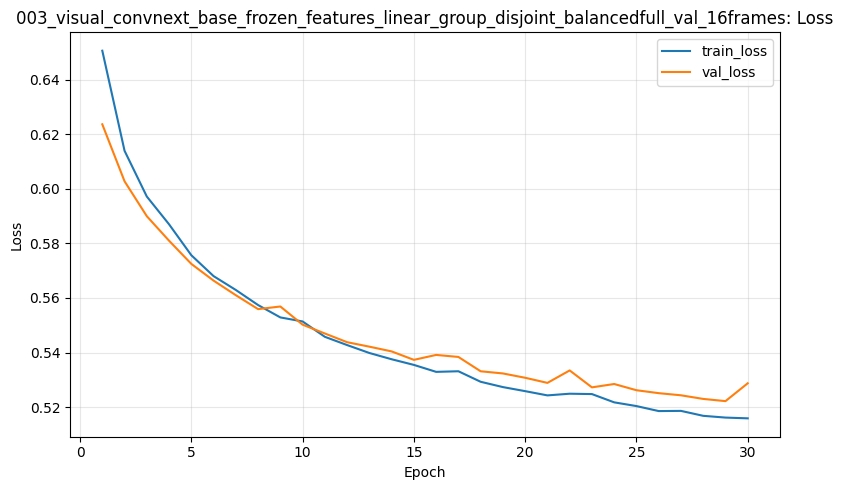

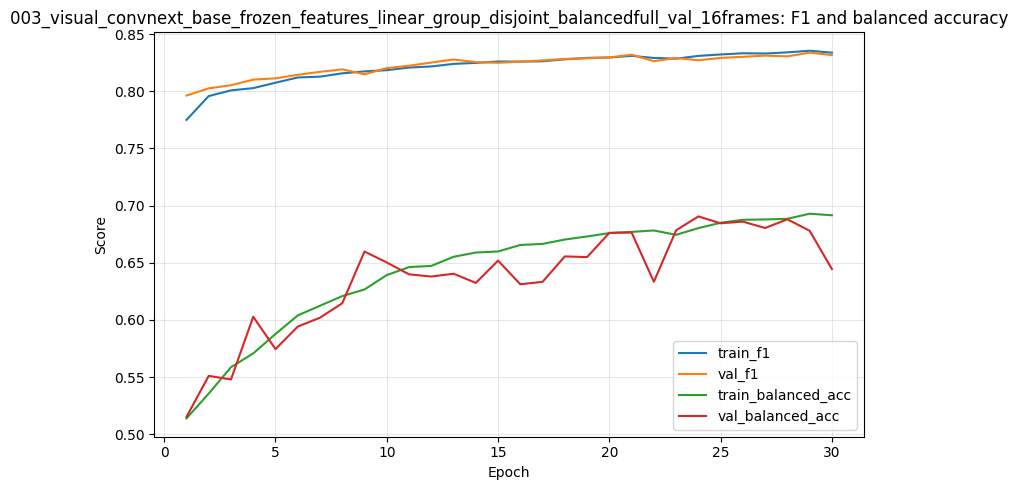

In [18]:
history_df = pd.DataFrame(history)

def save_curve(y_cols, title, ylabel, filename):
    plt.figure(figsize=(8, 5))
    for col in y_cols:
        if col in history_df.columns:
            plt.plot(history_df["epoch"], history_df[col], label=col)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=200)
    plt.show()

save_curve(["train_loss", "val_loss"], f"{RUN_NAME}: Loss", "Loss", f"{RUN_NAME}_loss_curve.png")
save_curve(["train_f1", "val_f1", "train_balanced_acc", "val_balanced_acc"], f"{RUN_NAME}: F1 and balanced accuracy", "Score", f"{RUN_NAME}_f1_balanced_accuracy.png")

## 17. Test evaluation

In [19]:
checkpoint_path = CHECKPOINT_DIR / f"{RUN_NAME}_linear_classifier_best.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)
feature_clf.load_state_dict(checkpoint["model_state_dict"])

test_metrics, y_true, y_pred, y_prob = evaluate_feature_classifier(
    feature_clf,
    test_clf_loader,
    criterion,
    device,
)

print(test_metrics)

pd.DataFrame([test_metrics]).to_csv(
    RESULTS_DIR / f"{RUN_NAME}_test_metrics.csv",
    index=False,
)

{'loss': 0.5181088530789617, 'acc': 0.7550541717859935, 'balanced_acc': 0.6831529134039588, 'f1': 0.8303288201160541, 'precision': 0.7604875283446711, 'recall': 0.9142954506730278, 'auc': 0.7970680767001275}


## 18. Confusion matrix and ROC

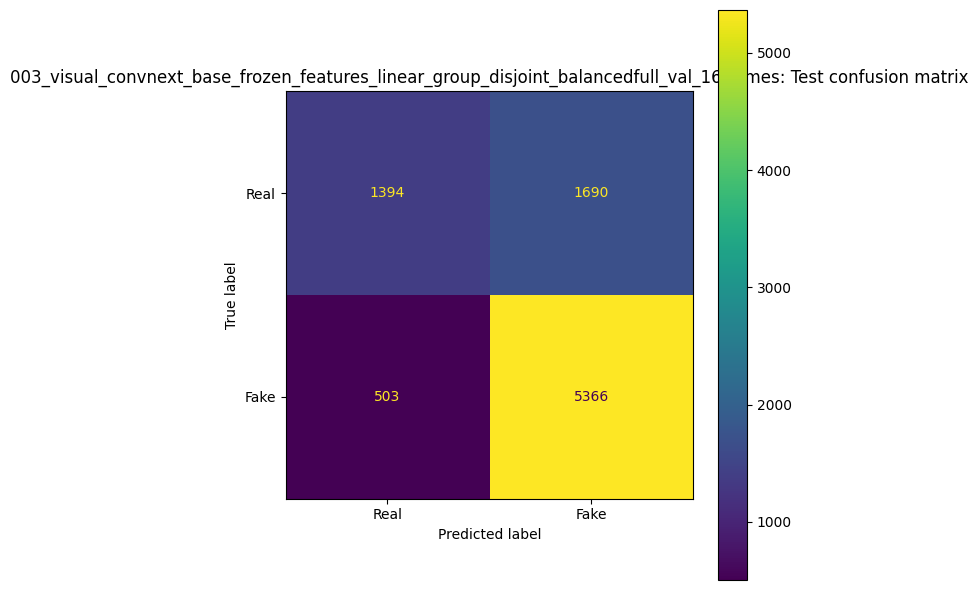

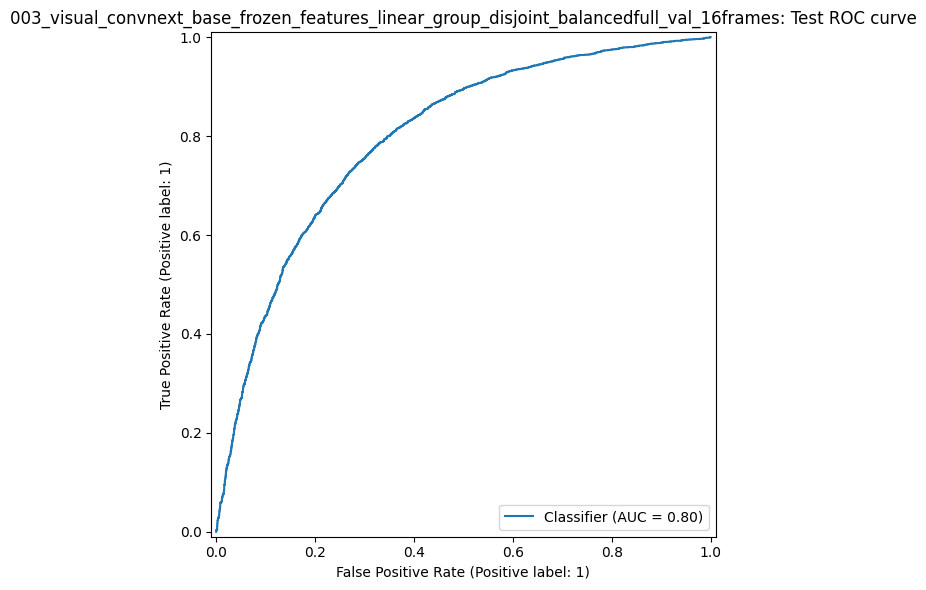

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Real", "Fake"],
    values_format="d",
    ax=ax,
)
plt.title(f"{RUN_NAME}: Test confusion matrix")
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_confusion_matrix.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(
    y_true,
    y_prob,
    ax=ax,
)
plt.title(f"{RUN_NAME}: Test ROC curve")
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_roc_curve.png", dpi=200)
plt.show()

## 19. Predictions and condition-level metrics

In [21]:
test_results_df = pd.read_csv(test_csv).reset_index(drop=True)
test_results_df["y_true"] = y_true
test_results_df["y_pred"] = y_pred
test_results_df["fake_probability"] = y_prob

test_predictions_path = RESULTS_DIR / f"{RUN_NAME}_test_predictions.csv"
test_results_df.to_csv(test_predictions_path, index=False)
print("Saved predictions:", test_predictions_path)

condition_rows = []

for condition, group in test_results_df.groupby(CONDITION_COL):
    true_labels = group["y_true"].unique().tolist()
    predicted_fake_rate = group["y_pred"].mean()
    mean_fake_probability = group["fake_probability"].mean()

    if len(true_labels) == 1:
        true_label = int(true_labels[0])
        if true_label == 1:
            condition_success_rate = predicted_fake_rate
            interpretation = "fake recall"
        else:
            condition_success_rate = 1 - predicted_fake_rate
            interpretation = "real recall"
    else:
        true_label = "mixed"
        condition_success_rate = accuracy_score(group["y_true"], group["y_pred"])
        interpretation = "accuracy"

    condition_rows.append({
        "condition": condition,
        "n": len(group),
        "true_label": true_label,
        "condition_success_rate": condition_success_rate,
        "interpretation": interpretation,
        "predicted_fake_rate": predicted_fake_rate,
        "mean_fake_probability": mean_fake_probability,
    })

condition_metrics_df = pd.DataFrame(condition_rows).sort_values("condition")
condition_metrics_path = RESULTS_DIR / f"{RUN_NAME}_condition_metrics_clean.csv"
condition_metrics_df.to_csv(condition_metrics_path, index=False)

display(condition_metrics_df)
print("Saved:", condition_metrics_path)

Saved predictions: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/results/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_test_predictions.csv


,condition,n,true_label,condition_success_rate,interpretation,predicted_fake_rate,mean_fake_probability
0,fake_video_fake_audio,1922,1,0.910510,fake recall,0.910510,0.739604
1,fake_video_real_audio,1981,1,0.911661,fake recall,0.911661,0.740993
2,real,3084,0,0.452010,real recall,0.547990,0.528334
3,real_video_fake_audio,1966,1,0.920651,fake recall,0.920651,0.746877


Saved: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/results/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_condition_metrics_clean.csv


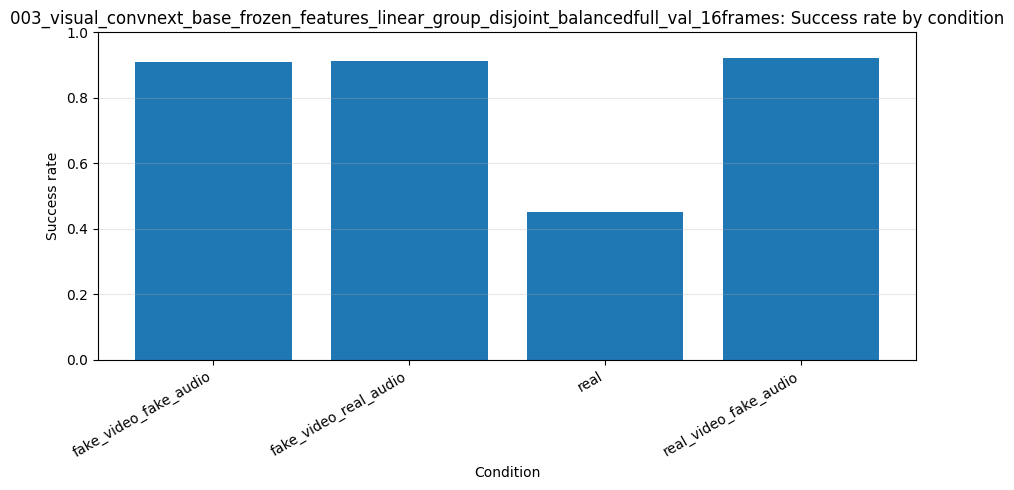

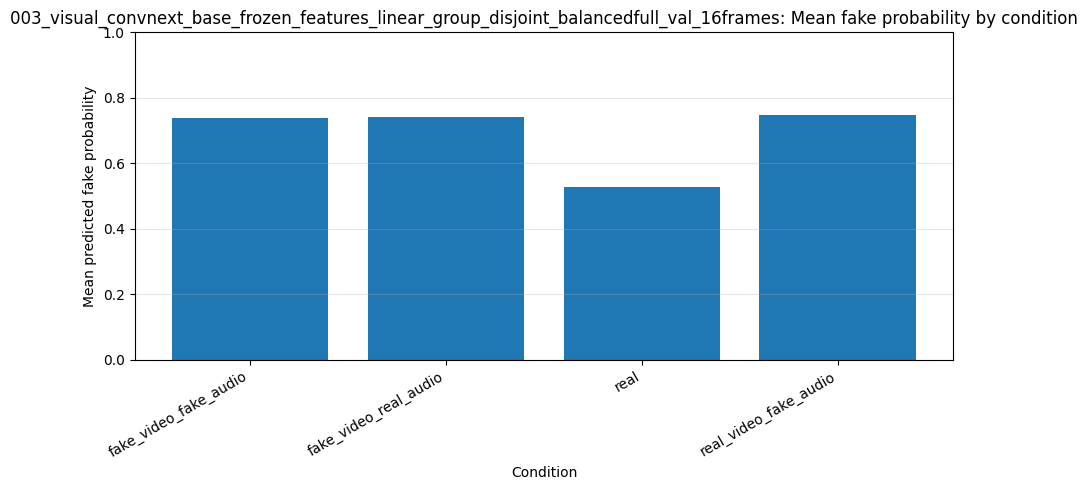

In [22]:
plt.figure(figsize=(9, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["condition_success_rate"])
plt.xlabel("Condition")
plt.ylabel("Success rate")
plt.title(f"{RUN_NAME}: Success rate by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_condition_success_rate.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["mean_fake_probability"])
plt.xlabel("Condition")
plt.ylabel("Mean predicted fake probability")
plt.title(f"{RUN_NAME}: Mean fake probability by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{RUN_NAME}_condition_fake_probability.png", dpi=200)
plt.show()

## 20. Archive index, final notebook snapshot, and zip export

In [23]:
def create_experiment_index(run_dirs):
    run_dir = Path(run_dirs["run"])
    rows = []

    for section, folder in run_dirs.items():
        folder = Path(folder)
        if not folder.exists() or not folder.is_dir():
            continue

        for file in folder.rglob("*"):
            if file.is_file():
                rows.append({
                    "section": section,
                    "filename": file.name,
                    "path": str(file),
                    "size_mb": file.stat().st_size / 1024**2,
                    "modified_at": datetime.fromtimestamp(file.stat().st_mtime).isoformat(timespec="seconds"),
                })

    index_df = pd.DataFrame(rows)
    index_path = run_dir / "archive_index.csv"
    index_df.to_csv(index_path, index=False)
    print("Experiment index saved:", index_path)
    display(index_df)
    return index_df

experiment_index_df = create_experiment_index(RUN_DIRS)

Experiment index saved: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/archive_index.csv


,section,filename,path,size_mb,modified_at
0,run,split_summary.json,/home/jovyan/MSC_PROJECT/experiments/003_visua...,0.000948,2026-07-13T21:14:24
1,run,config.json,/home/jovyan/MSC_PROJECT/experiments/003_visua...,0.001029,2026-07-13T21:14:23
2,run,val_features_000096.pt,/home/jovyan/MSC_PROJECT/experiments/003_visua...,0.064857,2026-07-13T22:11:39
3,run,val_features_000066.pt,/home/jovyan/MSC_PROJECT/experiments/003_visua...,0.064857,2026-07-13T22:10:21
4,run,val_features_000247.pt,/home/jovyan/MSC_PROJECT/experiments/003_visua...,0.064857,2026-07-13T22:18:16
...,...,...,...,...,...
3801,features,train_features_000023.pt,/home/jovyan/MSC_PROJECT/experiments/003_visua...,0.033377,2026-07-13T21:13:51
3802,features,train_features_000001.pt,/home/jovyan/MSC_PROJECT/experiments/003_visua...,0.033377,2026-07-13T21:13:34
3803,features,train_features_000013.pt,/home/jovyan/MSC_PROJECT/experiments/003_visua...,0.033377,2026-07-13T21:13:43
3804,features,train_features_000003.pt,/home/jovyan/MSC_PROJECT/experiments/003_visua...,0.033377,2026-07-13T21:13:35


In [24]:
# Press Ctrl+S before running this cell.
final_snapshot_path = RUN_DIRS["notebook"] / f"{RUN_NAME}_final_notebook_snapshot.ipynb"

if NOTEBOOK_PATH.exists():
    shutil.copy2(NOTEBOOK_PATH, final_snapshot_path)
    print("Final notebook snapshot saved:", final_snapshot_path)
else:
    print("Notebook path not found:", NOTEBOOK_PATH)

Final notebook snapshot saved: /home/jovyan/MSC_PROJECT/experiments/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames/notebook/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_final_notebook_snapshot.ipynb


In [25]:
import zipfile
from IPython.display import FileLink, display

EXPORTS_DIR = PROJECT_ROOT / "exports"
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

def zip_experiment_folder(run_dir, exports_dir, include_feature_shards=False):
    run_dir = Path(run_dir)
    exports_dir = Path(exports_dir)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    zip_path = exports_dir / f"{run_dir.name}_{timestamp}.zip"

    files = [p for p in run_dir.rglob("*") if p.is_file()]
    filtered_files = []

    for file in files:
        rel = file.relative_to(run_dir)

        if ".ipynb_checkpoints" in rel.parts or "__pycache__" in rel.parts:
            continue

        # Feature shards may be large. By default, keep them out of the zip.
        if not include_feature_shards and "features" in rel.parts and file.suffix == ".pt":
            continue

        filtered_files.append(file)

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for file in tqdm(filtered_files, desc=f"Zipping {run_dir.name}", leave=False):
            arcname = file.relative_to(run_dir.parent)
            zipf.write(file, arcname=arcname)

    print("Created zip:", zip_path)
    print(f"Zip size: {zip_path.stat().st_size / 1024**2:.2f} MB")
    return zip_path

zip_path = zip_experiment_folder(
    RUN_DIRS["run"],
    EXPORTS_DIR,
    include_feature_shards=False,
)

display(FileLink(str(zip_path)))

Created zip: /home/jovyan/MSC_PROJECT/exports/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_20260713_224621.zip
Zip size: 4.48 MB


/home/jovyan/MSC_PROJECT/exports/003_visual_convnext_base_frozen_features_linear_group_disjoint_balancedfull_val_16frames_20260713_224621.zip